In [8]:
import sys
print(sys.executable)

c:\Users\admin\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
import torch
from torch import nn,optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# test_path  = r"C:\Users\admin\Desktop\Python youtube class\python practice\brain_tumer_dataset\Testing"

tf = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_dl = DataLoader(
    datasets.ImageFolder( r"C:\Users\admin\Desktop\Python youtube class\python practice\brain_tumor_dataset\Training",tf),
    batch_size=16,shuffle=True, num_workers=4,pin_memory=False
)
train_dl = DataLoader(
    datasets.ImageFolder( r"C:\Users\admin\Desktop\Python youtube class\python practice\brain_tumor_dataset\Training",tf),
    batch_size=16,shuffle=False, num_workers=4,pin_memory=False
)

# ✅ 👉 CREATE TEST LOADER RIGHT HERE
test_dl = DataLoader(
    datasets.ImageFolder(r"C:\Users\admin\Desktop\Python youtube class\python practice\brain_tumor_dataset\Testing", tf),
    batch_size=16,
    shuffle=False,
    num_workers=4
)



In [4]:
model = nn.Sequential(
    nn.Conv2d(3,32,3,1,1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32,64,3,1,1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64,128,3,1,1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(256,4) #4 classes
).to(device)

In [5]:
opt = optim.AdamW(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
model.train()

for epoch in range(5):
    running_loss =0

    for x,y in train_dl:
        opt.zero_grad()

        loss = loss_fn(model(x.to(device)), y.to(device))
        loss.backward()

        running_loss += loss.item()

        opt.step()
    
    print(f'Epoch {epoch+1}: Loss was {running_loss}')

Epoch 1: Loss was 262.45831298828125
Epoch 2: Loss was 255.8610382080078


In [6]:
model.eval()
test_loss, correct = 0.0,0

with torch.no_grad():
    for x,y in test_dl:
        x,y = x.to(device),y.to(device)

        logits = model(x)
        test_loss += loss_fn(logits,y).item() * y.size(0)

        preds = logits.argmax(dim=1)
        correct +=(preds == y).sum().item()

test_loss /= len(test_dl.dataset)
accuracy = 100.0 * correct / len(test_dl.dataset) 
print(f"Test Loss:{test_loss:.4f}, Test accuracy:{accuracy:.2f}%")

Test Loss:1.3865, Test accuracy:18.31%


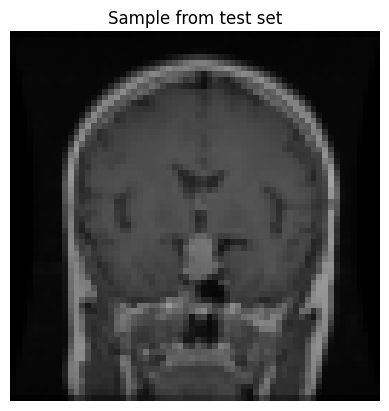

Predicated class:meningioma
Ground-truth:pituitary


In [11]:
import random 

import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

model.eval()

idx = random.randrange(len(test_dl.dataset))
img, label = test_dl.dataset[idx]

unnorm = img * 0.5 + 0.5
plt.imshow(to_pil_image(unnorm))
plt.axis('off')
plt.title('Sample from test set')
plt.show()

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    pred = logits.argmax(1).item()

class_names = test_dl.dataset.classes
print(f"Predicated class:{class_names[pred]}")
print(f"Ground-truth:{class_names[label]}")

In [1]:
!pip freeze > requirements.txt